# Suivi des Programmes de Développement — Région Sahel
## Sahel Program Monitor | LuxDev - Tableau de bord analytique

---

### Contexte opérationnel

Le Sahel est l'une des régions les plus fragiles du monde : insécurité alimentaire,
changement climatique, conflits et déplacements de population affectent des millions
de personnes. Les programmes de développement financés par des bailleurs comme
**LuxDev, l'AFD, l'UE et le FIDA** interviennent dans ce contexte pour renforcer
la résilience des communautés.

**Suivre la performance de ces programmes n'est pas un exercice administratif —
c'est une question d'impact humanitaire.**

Ce notebook analyse la performance de **6 programmes fictifs** représentatifs
des interventions au Sahel : agriculture, eau & assainissement, nutrition,
éducation, gouvernance locale et résilience climatique.

### Ce que vous allez voir

1. **Vue d'ensemble** : performance globale des programmes
2. **Analyse par secteur** : quels secteurs atteignent leurs cibles ?
3. **Évolution temporelle** : progression sur 12 mois
4. **Alertes et risques** : programmes en difficulté
5. **Recommandations** : actions prioritaires pour les coordinateurs

### À qui s'adresse ce notebook ?

- **Coordinateurs de programmes** qui suivent les indicateurs
- **Chargés de suivi-évaluation (MEL)** qui produisent les rapports
- **Bailleurs et partenaires** qui veulent comprendre l'impact
- **Aucune connaissance technique requise** pour lire les résultats

## Étape 1 : Chargement des outils d'analyse

Nous chargeons les bibliothèques Python nécessaires à l'analyse
et créons les données de démonstration représentatives
des programmes Sahel.

In [1]:
# ─────────────────────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

np.random.seed(42)

# ─────────────────────────────────────────────────────────────
# Données simulées — Programmes LuxDev Sahel
# ─────────────────────────────────────────────────────────────

# Programmes
df_programmes = pd.DataFrame({
    'code': ['SAH-AGR-01', 'SAH-EAU-02', 'SAH-NUT-03',
             'SAH-EDU-04', 'SAH-GOV-05', 'SAH-CLI-06'],
    'nom': [
        'Programme Agriculture Durable — Niger',
        'Eau & Assainissement Rural — Mali',
        'Nutrition & Sécurité Alimentaire — Burkina Faso',
        'Éducation Inclusive — Mauritanie',
        'Gouvernance Locale — Sénégal',
        'Résilience Climatique — Tchad'
    ],
    'pays': ['Niger', 'Mali', 'Burkina Faso', 'Mauritanie', 'Sénégal', 'Tchad'],
    'secteur': ['Agriculture', 'Eau & WASH', 'Nutrition', 
                'Éducation', 'Gouvernance', 'Résilience'],
    'budget_eur': [3_200_000, 2_800_000, 1_900_000, 
                   2_400_000, 1_600_000, 3_500_000],
    'bailleur': ['LuxDev', 'LuxDev', 'UE', 'AFD', 'LuxDev', 'FIDA'],
    'date_debut': pd.to_datetime(['2022-01-01', '2021-06-01', '2023-01-01',
                                   '2022-09-01', '2021-01-01', '2023-06-01']),
    'date_fin':   pd.to_datetime(['2025-12-31', '2025-06-30', '2025-12-31',
                                   '2026-08-31', '2024-12-31', '2026-05-31']),
    'performance': [87.3, 72.1, 91.5, 65.8, 78.4, 95.2],
    'statut': ['En cours', 'En cours', 'En cours', 
               'En difficulté', 'En cours', 'En cours']
})

# Indicateurs par programme
indicateurs = []
for _, prog in df_programmes.iterrows():
    base_perf = prog['performance'] / 100
    indicateurs.extend([
        {'programme': prog['code'], 'pays': prog['pays'],
         'secteur': prog['secteur'],
         'indicateur': 'Bénéficiaires directs atteints',
         'unite': 'personnes',
         'cible': 10000, 
         'realise': int(10000 * base_perf * np.random.uniform(0.9, 1.1))},
        {'programme': prog['code'], 'pays': prog['pays'],
         'secteur': prog['secteur'],
         'indicateur': 'Ménages touchés',
         'unite': 'ménages',
         'cible': 2000,
         'realise': int(2000 * base_perf * np.random.uniform(0.85, 1.05))},
        {'programme': prog['code'], 'pays': prog['pays'],
         'secteur': prog['secteur'],
         'indicateur': 'Activités réalisées',
         'unite': '%',
         'cible': 100,
         'realise': round(base_perf * 100 * np.random.uniform(0.92, 1.0), 1)},
    ])

df_indicateurs = pd.DataFrame(indicateurs)
df_indicateurs['taux_realisation'] = (
    df_indicateurs['realise'] / df_indicateurs['cible'] * 100
).round(1)

# Évolution mensuelle sur 12 mois
mois = pd.date_range('2025-01-01', periods=12, freq='MS')
evolution = []
for _, prog in df_programmes.iterrows():
    base = prog['performance']
    for i, m in enumerate(mois):
        perf = base * (0.7 + 0.3 * (i / 11)) * np.random.uniform(0.95, 1.05)
        evolution.append({
            'programme': prog['code'],
            'pays': prog['pays'],
            'secteur': prog['secteur'],
            'mois': m,
            'performance': round(min(perf, 100), 1),
            'cible': 100
        })

df_evolution = pd.DataFrame(evolution)

# Alertes
df_alertes = pd.DataFrame([
    {'programme': 'SAH-EDU-04', 'pays': 'Mauritanie',
     'type': 'Retard', 'niveau': 'Élevé',
     'message': 'Taux de réalisation < 70% — révision du plan requis'},
    {'programme': 'SAH-EAU-02', 'pays': 'Mali',
     'type': 'Sécurité', 'niveau': 'Moyen',
     'message': 'Accès terrain limité dans 3 communes — retard possible'},
    {'programme': 'SAH-AGR-01', 'pays': 'Niger',
     'type': 'Budget', 'niveau': 'Faible',
     'message': 'Taux de décaissement à 82% — surveillance recommandée'},
])

print("✓ Données chargées avec succès")
print(f"  • {len(df_programmes)} programmes")
print(f"  • {len(df_indicateurs)} indicateurs")
print(f"  • {len(df_evolution)} points d'évolution (12 mois)")
print(f"  • {len(df_alertes)} alertes actives")
print(f"\n  Budget total : {df_programmes['budget_eur'].sum()/1e6:.1f}M€")
print(f"  Performance moyenne : {df_programmes['performance'].mean():.1f}%")

✓ Données chargées avec succès
  • 6 programmes
  • 18 indicateurs
  • 72 points d'évolution (12 mois)
  • 3 alertes actives

  Budget total : 15.4M€
  Performance moyenne : 81.7%


## Étape 2 : Vue d'ensemble des programmes

### Comment lire les graphiques suivants ?

Nous allons visualiser la **performance globale** de chaque programme, 
c'est-à-dire le pourcentage d'atteinte des cibles fixées au démarrage.

**Interprétation du taux de réalisation :**
- 🟢 **≥ 85%** : Programme sur la bonne voie
- 🟡 **70% à 84%** : Programme à surveiller
- 🔴 **< 70%** : Programme en difficulté -> action corrective requise

**Pourquoi ce seuil de 70% ?**
C'est le seuil standard utilisé par la plupart des bailleurs
(LuxDev, AFD, UE) pour déclencher une révision de programme.
En dessous de ce niveau, le programme risque de ne pas atteindre
ses objectifs avant la date de clôture.

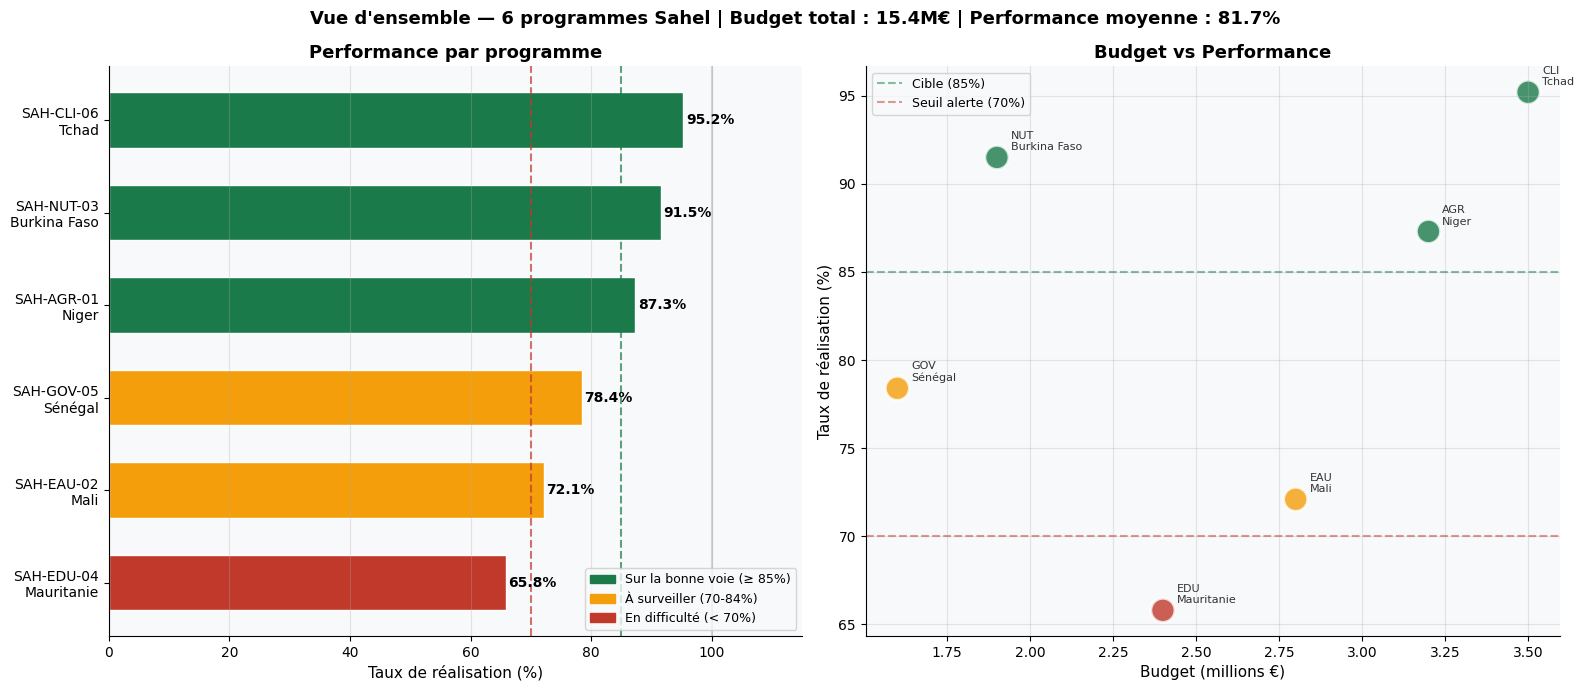

✓ Graphique sauvegardé


In [2]:
# Vue d'ensemble des programmes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphique 1 : Performance par programme ───────────────────
ax1 = axes[0]

df_sorted = df_programmes.sort_values('performance')
colors = ['#c0392b' if p < 70 else '#f59e0b' if p < 85 else '#1a7a4a' 
          for p in df_sorted['performance']]

bars = ax1.barh(
    [f"{row['code']}\n{row['pays']}" for _, row in df_sorted.iterrows()],
    df_sorted['performance'],
    color=colors, height=0.6, edgecolor='white'
)

# Labels
for bar, perf in zip(bars, df_sorted['performance']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{perf}%', va='center', fontsize=10, fontweight='bold')

# Seuils
ax1.axvline(x=70, color='#c0392b', linestyle='--', 
            alpha=0.7, label='Seuil alerte (70%)')
ax1.axvline(x=85, color='#1a7a4a', linestyle='--', 
            alpha=0.7, label='Cible (85%)')
ax1.axvline(x=100, color='gray', linestyle='-', alpha=0.3)

ax1.set_xlim(0, 115)
ax1.set_xlabel('Taux de réalisation (%)', fontsize=11)
ax1.set_title('Performance par programme', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# Légende couleurs
patches = [
    mpatches.Patch(color='#1a7a4a', label='Sur la bonne voie (≥ 85%)'),
    mpatches.Patch(color='#f59e0b', label='À surveiller (70-84%)'),
    mpatches.Patch(color='#c0392b', label='En difficulté (< 70%)'),
]
ax1.legend(handles=patches, fontsize=9, loc='lower right')

# ── Graphique 2 : Budget vs Performance ───────────────────────
ax2 = axes[1]

scatter_colors = ['#c0392b' if p < 70 else '#f59e0b' if p < 85 else '#1a7a4a'
                  for p in df_programmes['performance']]

scatter = ax2.scatter(
    df_programmes['budget_eur'] / 1e6,
    df_programmes['performance'],
    c=scatter_colors, s=300, alpha=0.8, edgecolors='white', linewidth=2
)

# Labels des points
for _, row in df_programmes.iterrows():
    ax2.annotate(
        row['code'].split('-')[1] + '\n' + row['pays'],
        (row['budget_eur']/1e6, row['performance']),
        textcoords="offset points", xytext=(10, 5),
        fontsize=8, color='#333'
    )

ax2.axhline(y=85, color='#1a7a4a', linestyle='--', alpha=0.5, label='Cible (85%)')
ax2.axhline(y=70, color='#c0392b', linestyle='--', alpha=0.5, label='Seuil alerte (70%)')

ax2.set_xlabel('Budget (millions €)', fontsize=11)
ax2.set_ylabel('Taux de réalisation (%)', fontsize=11)
ax2.set_title('Budget vs Performance', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(
    f'Vue d\'ensemble — 6 programmes Sahel | Budget total : '
    f'{df_programmes["budget_eur"].sum()/1e6:.1f}M€ | '
    f'Performance moyenne : {df_programmes["performance"].mean():.1f}%',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig('notebooks/overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

In [3]:
import os
print(os.getcwd())

C:\Users\nyams\projects\sahel-program-monitor


## Étape 3 : Analyse par secteur

### Quels secteurs atteignent leurs cibles ?

Les programmes du Sahel couvrent 6 secteurs d'intervention.
Chaque secteur a ses propres défis terrain :

- **Agriculture** : dépendance aux saisons, aléas climatiques
- **Eau & WASH** : délais de construction, qualité des forages
- **Nutrition** : saisonnalité de la malnutrition, accès communautaire
- **Éducation** : taux d'inscription, rétention des filles
- **Gouvernance** : processus politiques, engagement des autorités
- **Résilience climatique** : indicateurs à long terme, difficiles à mesurer

Cette analyse permet au coordinateur de programme d'identifier
**quels secteurs nécessitent un appui renforcé** et lesquels
peuvent servir de modèle pour les autres.

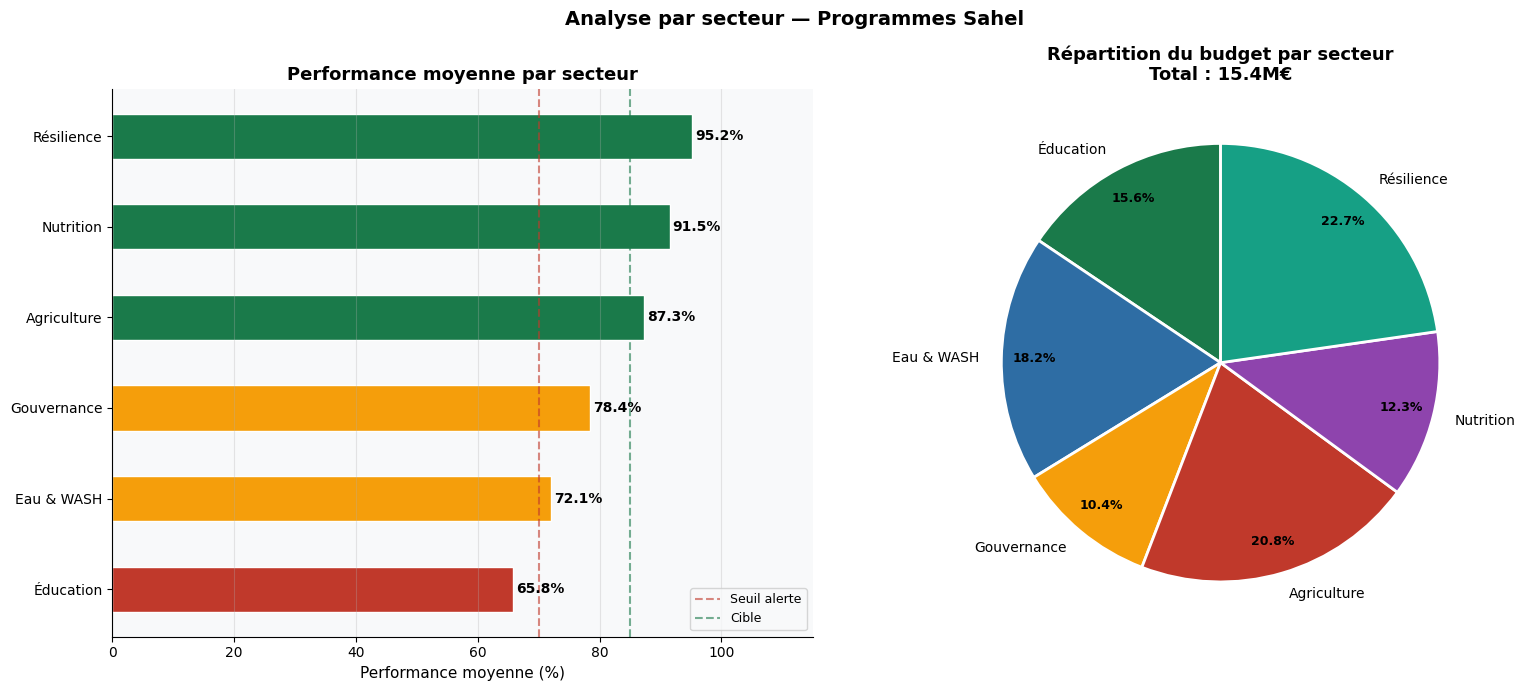


Récapitulatif par secteur :
-----------------------------------------------------------------
Secteur                    Performance       Budget       Statut
-----------------------------------------------------------------
Résilience                      95.2%       3.5M€         ✓ OK
Nutrition                       91.5%       1.9M€         ✓ OK
Agriculture                     87.3%       3.2M€         ✓ OK
Gouvernance                     78.4%       1.6M€ ⚠ Surveillance
Eau & WASH                      72.1%       2.8M€ ⚠ Surveillance
Éducation                       65.8%       2.4M€     ✗ Alerte
-----------------------------------------------------------------
TOTAL / MOYENNE                 81.7%      15.4M€


In [4]:
# Analyse par secteur
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphique 1 : Performance par secteur ────────────────────
ax1 = axes[0]

df_secteur = df_programmes.groupby('secteur').agg(
    performance=('performance', 'mean'),
    budget=('budget_eur', 'sum'),
    nb_programmes=('code', 'count')
).reset_index().sort_values('performance')

colors = ['#c0392b' if p < 70 else '#f59e0b' if p < 85 else '#1a7a4a'
          for p in df_secteur['performance']]

bars = ax1.barh(df_secteur['secteur'], df_secteur['performance'],
                color=colors, height=0.5, edgecolor='white')

for bar, perf in zip(bars, df_secteur['performance']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{perf:.1f}%', va='center', fontsize=10, fontweight='bold')

ax1.axvline(x=70, color='#c0392b', linestyle='--', alpha=0.6, label='Seuil alerte')
ax1.axvline(x=85, color='#1a7a4a', linestyle='--', alpha=0.6, label='Cible')
ax1.set_xlim(0, 115)
ax1.set_xlabel('Performance moyenne (%)', fontsize=11)
ax1.set_title('Performance moyenne par secteur', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# ── Graphique 2 : Budget par secteur (camembert) ─────────────
ax2 = axes[1]

colors_pie = ['#1a7a4a', '#2E6DA4', '#f59e0b', 
              '#c0392b', '#8e44ad', '#16a085']

wedges, texts, autotexts = ax2.pie(
    df_secteur['budget'],
    labels=df_secteur['secteur'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax2.set_title('Répartition du budget par secteur\n'
              f'Total : {df_secteur["budget"].sum()/1e6:.1f}M€',
              fontsize=13, fontweight='bold')

plt.suptitle('Analyse par secteur — Programmes Sahel',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/secteur_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau récapitulatif
print("\nRécapitulatif par secteur :")
print("-" * 65)
print(f"{'Secteur':<25} {'Performance':>12} {'Budget':>12} {'Statut':>12}")
print("-" * 65)
for _, row in df_secteur.sort_values('performance', ascending=False).iterrows():
    statut = "✓ OK" if row['performance'] >= 85 else "⚠ Surveillance" if row['performance'] >= 70 else "✗ Alerte"
    print(f"{row['secteur']:<25} {row['performance']:>10.1f}% "
          f"{row['budget']/1e6:>9.1f}M€ {statut:>12}")
print("-" * 65)
print(f"{'TOTAL / MOYENNE':<25} {df_secteur['performance'].mean():>10.1f}% "
      f"{df_secteur['budget'].sum()/1e6:>9.1f}M€")

## Étape 4 : Évolution temporelle sur 12 mois

### Pourquoi suivre l'évolution dans le temps ?

Un taux de réalisation à un instant T ne dit pas tout.
Ce qui compte pour un coordinateur de programme, c'est la **trajectoire** :

- Un programme à 75% en janvier qui progresse régulièrement
  vers 90% en décembre est **sur la bonne voie**
- Un programme à 85% en janvier qui stagne ou régresse
  est **un signal d'alarme**

Cette analyse montre comment chaque programme a évolué
mois par mois sur les **12 derniers mois**.

### Ce qu'on cherche à détecter

- **Accélération** → programme qui rattrape son retard
- **Stagnation** → programme bloqué, besoin d'appui
- **Régression** → problème terrain sérieux, intervention urgente
- **Saisonnalité** → creux prévisibles (saison des pluies, Ramadan, etc.)

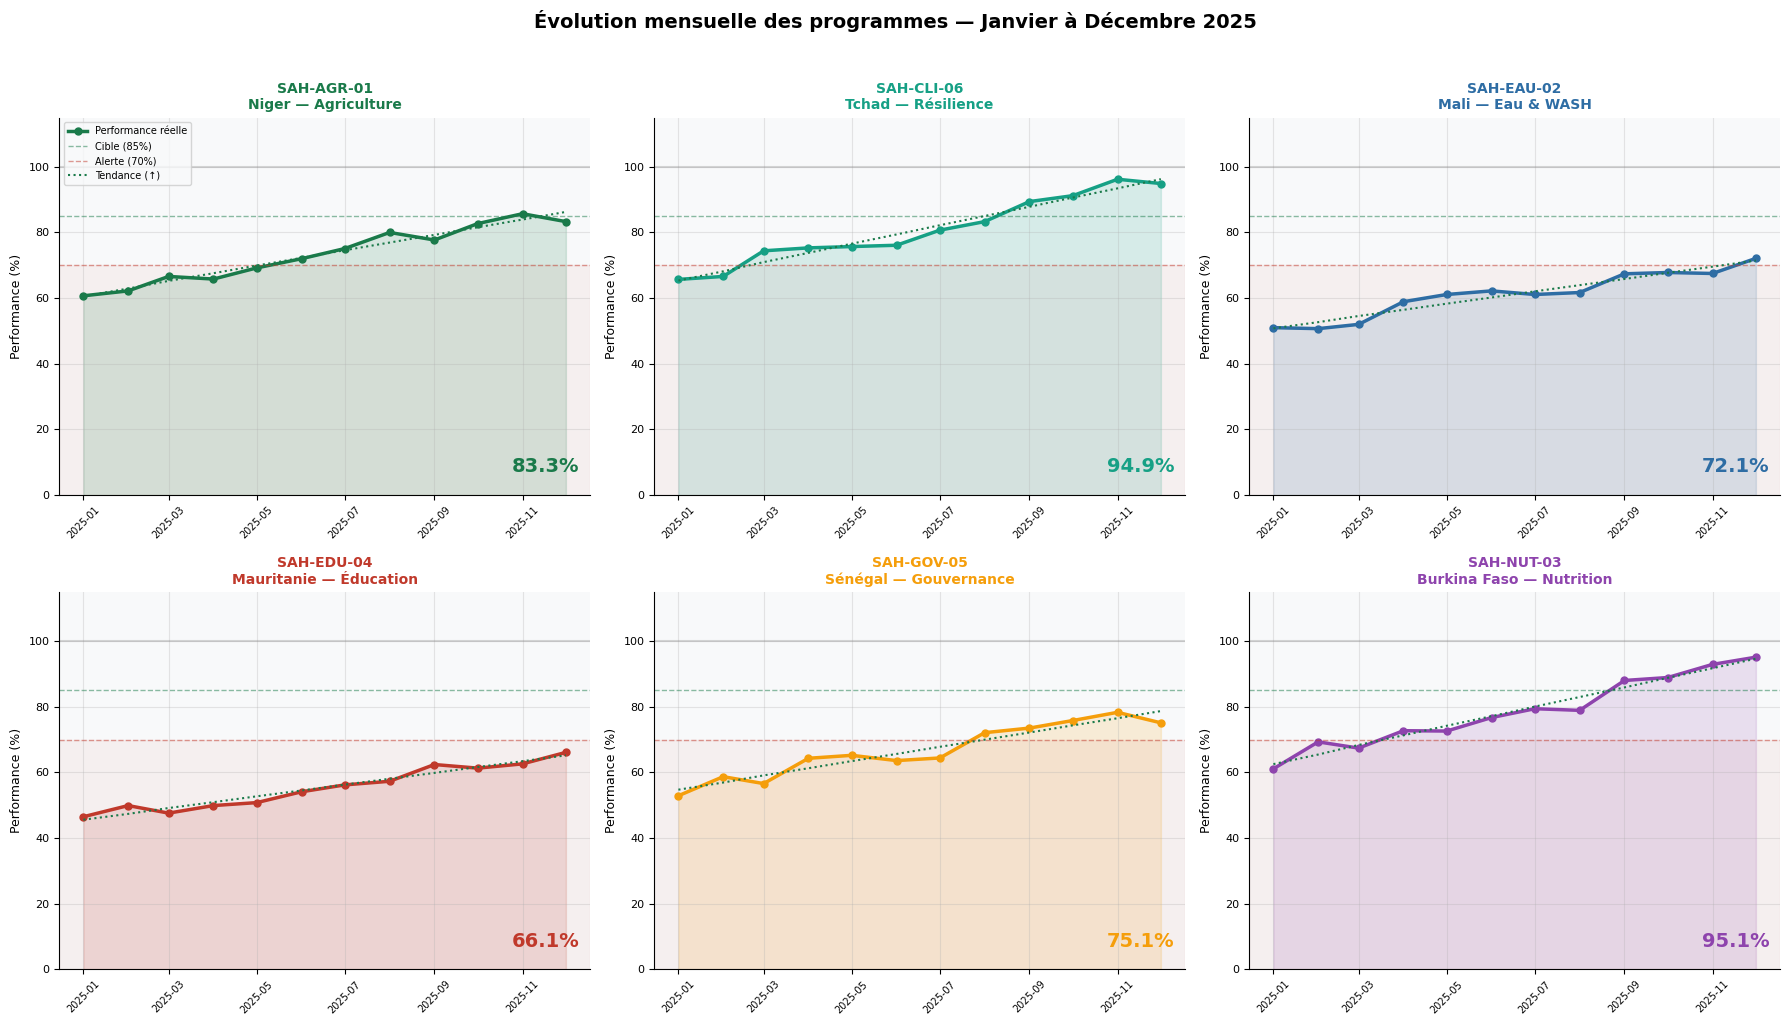

✓ Graphique sauvegardé


In [5]:
# Évolution temporelle sur 12 mois
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_prog = {
    'SAH-AGR-01': '#1a7a4a',
    'SAH-EAU-02': '#2E6DA4',
    'SAH-NUT-03': '#8e44ad',
    'SAH-EDU-04': '#c0392b',
    'SAH-GOV-05': '#f59e0b',
    'SAH-CLI-06': '#16a085'
}

for idx, (code, df_prog_evo) in enumerate(df_evolution.groupby('programme')):
    ax = axes[idx]
    prog_info = df_programmes[df_programmes['code'] == code].iloc[0]
    color = colors_prog.get(code, '#333')

    # Ligne de performance
    ax.plot(df_prog_evo['mois'], df_prog_evo['performance'],
            color=color, linewidth=2.5, marker='o', markersize=5,
            label='Performance réelle')

    # Zone remplie
    ax.fill_between(df_prog_evo['mois'], df_prog_evo['performance'],
                    alpha=0.15, color=color)

    # Seuils
    ax.axhline(y=100, color='gray', linestyle='-', alpha=0.3)
    ax.axhline(y=85, color='#1a7a4a', linestyle='--',
               alpha=0.5, linewidth=1, label='Cible (85%)')
    ax.axhline(y=70, color='#c0392b', linestyle='--',
               alpha=0.5, linewidth=1, label='Alerte (70%)')

    # Zone danger
    ax.axhspan(0, 70, alpha=0.05, color='#c0392b')

    # Tendance (ligne de régression)
    x_num = np.arange(len(df_prog_evo))
    z = np.polyfit(x_num, df_prog_evo['performance'], 1)
    p = np.poly1d(z)
    tendance = p(x_num)
    trend_color = '#1a7a4a' if z[0] > 0 else '#c0392b'
    ax.plot(df_prog_evo['mois'], tendance,
            color=trend_color, linestyle=':', linewidth=1.5,
            label=f'Tendance ({"↑" if z[0] > 0 else "↓"})')

    # Formatage
    ax.set_ylim(0, 115)
    ax.set_title(f"{code}\n{prog_info['pays']} — {prog_info['secteur']}",
                fontsize=10, fontweight='bold', color=color)
    ax.set_ylabel('Performance (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(alpha=0.3)

    # Performance finale
    perf_finale = df_prog_evo['performance'].iloc[-1]
    ax.text(0.98, 0.05, f'{perf_finale:.1f}%',
            transform=ax.transAxes,
            fontsize=14, fontweight='bold', color=color,
            ha='right', va='bottom')

    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Évolution mensuelle des programmes — Janvier à Décembre 2025',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

## Étape 5 : Alertes et gestion des risques

### Pourquoi un système d'alertes ?

Dans la gestion de programmes de développement et humanitaires, **anticiper les problèmes
vaut mieux que les subir**. Un système d'alertes permet de :

- Détecter les programmes en difficulté **avant** qu'ils dérapent
- Prioriser les missions de supervision terrain
- Informer les bailleurs de façon proactive
- Documenter les risques pour les rapports de suivi

### Les 3 niveaux d'alerte

| Niveau | Couleur | Signification | Action requise |
|--------|---------|---------------|----------------|
| **Élevé** | 🔴 Rouge | Performance < 70% ou risque majeur | Intervention immédiate |
| **Moyen** | 🟡 Jaune | Performance 70-79% ou risque modéré | Supervision renforcée |
| **Faible** | 🟢 Vert | Performance 80-84% ou risque mineur | Surveillance standard |

### Règle des feux de signalisation

Ce système de couleurs, appelé **"traffic light system"**
est utilisé par la plupart des bailleurs internationaux
(LuxDev, AFD, Banque Mondiale, PNUD) pour le suivi de performance.
Il permet à n'importe quel lecteur, technique ou non,
de comprendre immédiatement la situation d'un programme.

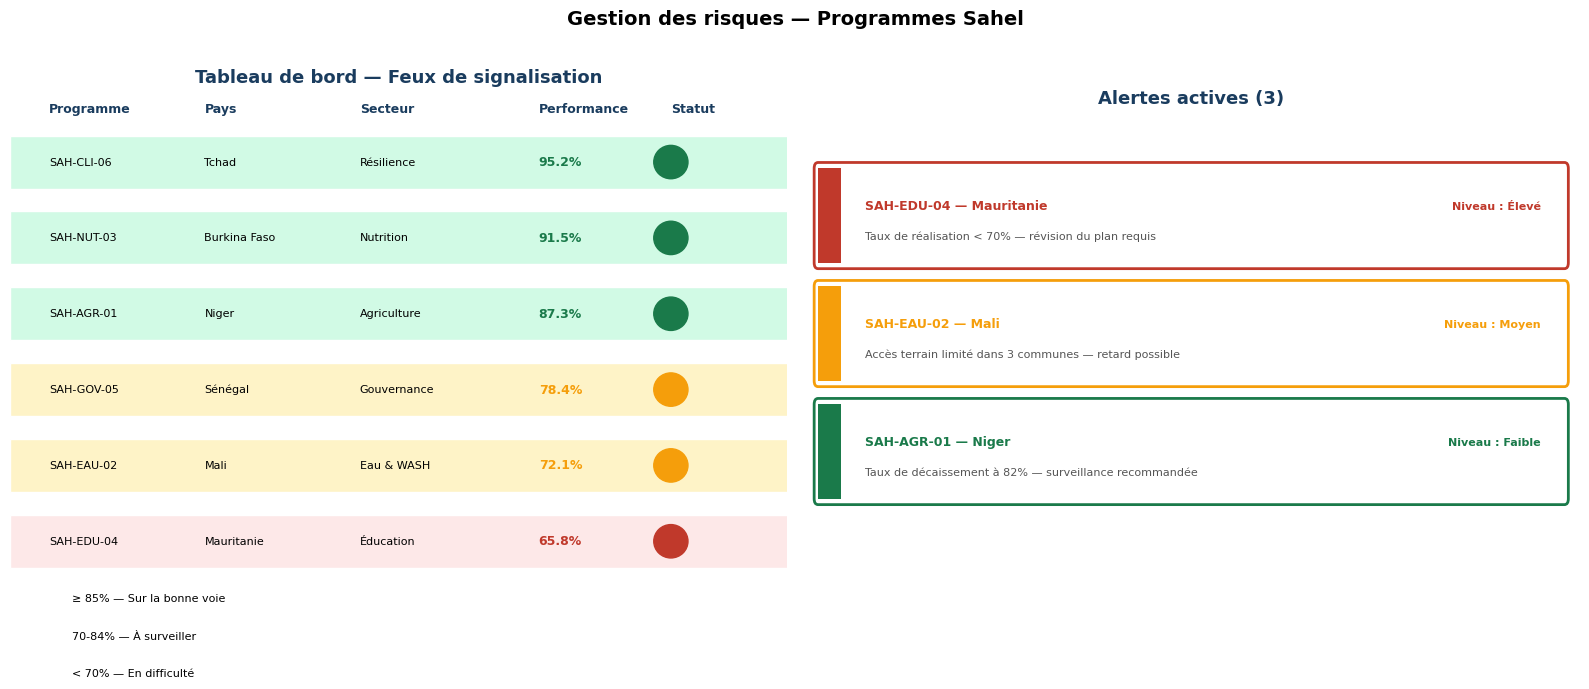

✓ Graphique sauvegardé


In [6]:
# Alertes et tableau de bord des risques
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphique 1 : Tableau de bord feux de signalisation ───────
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, len(df_programmes) + 1)
ax1.axis('off')

ax1.text(5, len(df_programmes) + 0.5,
         'Tableau de bord — Feux de signalisation',
         ha='center', fontsize=13, fontweight='bold', color='#1A3C5E')

headers = ['Programme', 'Pays', 'Secteur', 'Performance', 'Statut']
col_x = [0.5, 2.5, 4.5, 6.8, 8.5]

for j, (header, x) in enumerate(zip(headers, col_x)):
    ax1.text(x, len(df_programmes) + 0.1, header,
             fontsize=9, fontweight='bold', color='#1A3C5E')

for i, (_, row) in enumerate(
    df_programmes.sort_values('performance').iterrows()
):
    y = i + 0.3
    perf = row['performance']

    # Couleur de fond
    bg_color = '#fde8e8' if perf < 70 else '#fef3c7' if perf < 85 else '#d1fae5'
    rect = plt.Rectangle((0, y - 0.2), 10, 0.7,
                          facecolor=bg_color, edgecolor='white', linewidth=1)
    ax1.add_patch(rect)

    # Feu de signalisation
    dot_color = '#c0392b' if perf < 70 else '#f59e0b' if perf < 85 else '#1a7a4a'
    circle = plt.Circle((8.5, y + 0.15), 0.22,
                         color=dot_color, zorder=5)
    ax1.add_patch(circle)

    # Texte
    ax1.text(0.5, y + 0.15, row['code'], fontsize=8, va='center')
    ax1.text(2.5, y + 0.15, row['pays'], fontsize=8, va='center')
    ax1.text(4.5, y + 0.15, row['secteur'], fontsize=8, va='center')
    ax1.text(6.8, y + 0.15, f"{perf}%",
             fontsize=9, fontweight='bold', va='center', color=dot_color)

# Légende
for i, (label, color) in enumerate([
    ('≥ 85% — Sur la bonne voie', '#1a7a4a'),
    ('70-84% — À surveiller', '#f59e0b'),
    ('< 70% — En difficulté', '#c0392b')
]):
    circle = plt.Circle((0.5, -0.3 - i*0.5), 0.15, color=color)
    ax1.add_patch(circle)
    ax1.text(0.8, -0.3 - i*0.5, label, fontsize=8, va='center')

# ── Graphique 2 : Alertes actives ────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(-0.5, len(df_alertes) + 1)
ax2.axis('off')

ax2.text(5, len(df_alertes) + 0.5,
         f'Alertes actives ({len(df_alertes)})',
         ha='center', fontsize=13, fontweight='bold', color='#1A3C5E')

niveau_colors = {'Élevé': '#c0392b', 'Moyen': '#f59e0b', 'Faible': '#1a7a4a'}

for i, (_, alerte) in enumerate(df_alertes.iterrows()):
    y = len(df_alertes) - i - 0.5
    color = niveau_colors.get(alerte['niveau'], '#666')

    # Boîte alerte
    rect = mpatches.FancyBboxPatch((0.2, y - 0.35), 9.6, 0.8,
                               boxstyle="round,pad=0.05",
                               facecolor='white',
                               edgecolor=color, linewidth=2)
    ax2.add_patch(rect)

    # Barre latérale colorée
    bar = plt.Rectangle((0.2, y - 0.35), 0.3, 0.8, facecolor=color)
    ax2.add_patch(bar)

    # Texte
    ax2.text(0.8, y + 0.1,
             f"{alerte['programme']} — {alerte['pays']}",
             fontsize=9, fontweight='bold', color=color)
    ax2.text(0.8, y - 0.15, alerte['message'],
             fontsize=8, color='#555')
    ax2.text(9.5, y + 0.1,
             f"Niveau : {alerte['niveau']}",
             fontsize=8, color=color, ha='right', fontweight='bold')

plt.suptitle('Gestion des risques — Programmes Sahel',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/alertes_risques.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

## Étape 6 : Recommandations opérationnelles

### Comment utiliser ces résultats ?

Cette analyse produit des recommandations concrètes
pour les coordinateurs de programme et les chargés MEL.

### Principe de priorisation

Les recommandations suivent la règle des **3 urgences** :

**🔴 Urgence immédiate** à traiter dans les 30 jours
Pour les programmes avec performance < 70% ou alertes de niveau Élevé.
Action : mission de supervision terrain, révision du plan de travail,
réunion avec les partenaires locaux.

**🟡 Surveillance renforcée** à traiter dans les 90 jours
Pour les programmes avec performance entre 70% et 84%.
Action : appui technique ciblé, renforcement de capacités,
ajustement des activités.

**🟢 Bonnes pratiques** à capitaliser
Pour les programmes avec performance ≥ 85%.
Action : documenter les succès, partager avec les autres programmes,
intégrer dans les rapports bailleurs.

### Pourquoi documenter les succès ?

Dans le secteur du développement et de l'humanitaire, on documente beaucoup les problèmes
mais rarement les succès. Pourtant, **un programme qui fonctionne bien
contient les solutions pour les programmes en difficulté.**

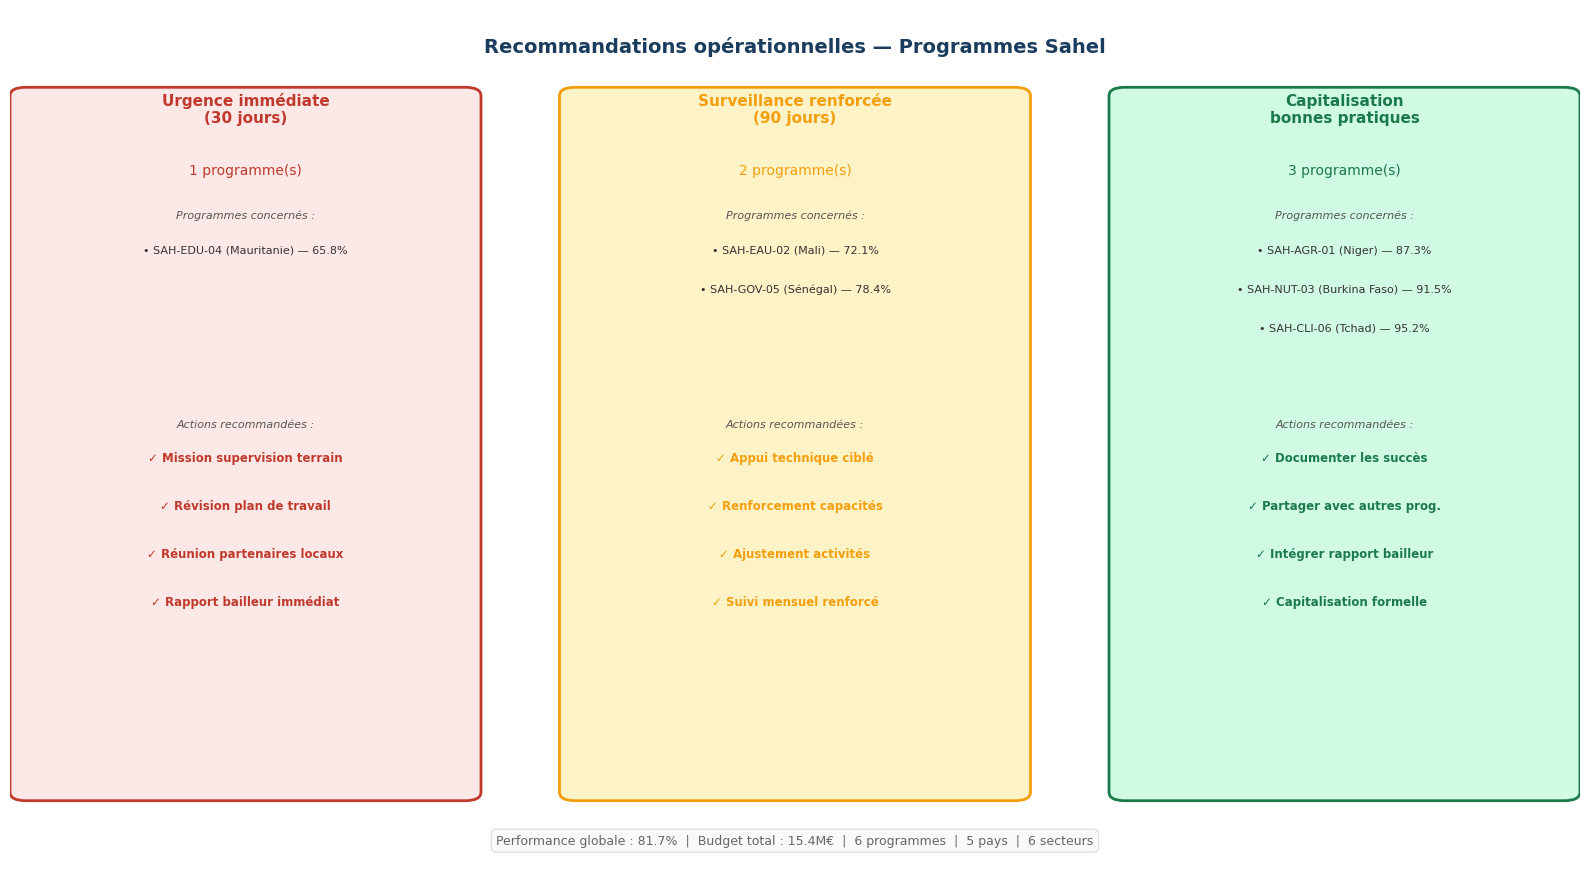

✓ Graphique sauvegardé


In [7]:
# Recommandations opérationnelles
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Titre
ax.text(5, 9.5, 'Recommandations opérationnelles — Programmes Sahel',
        ha='center', fontsize=14, fontweight='bold', color='#1A3C5E')

# Catégories
categories = {
    'Urgence immédiate\n(30 jours)': {
        'color': '#c0392b',
        'bg': '#fde8e8',
        'x': 1.5,
        'programmes': df_programmes[df_programmes['performance'] < 70],
        'actions': [
            'Mission supervision terrain',
            'Révision plan de travail',
            'Réunion partenaires locaux',
            'Rapport bailleur immédiat'
        ]
    },
    'Surveillance renforcée\n(90 jours)': {
        'color': '#f59e0b',
        'bg': '#fef3c7',
        'x': 5.0,
        'programmes': df_programmes[
            (df_programmes['performance'] >= 70) & 
            (df_programmes['performance'] < 85)
        ],
        'actions': [
            'Appui technique ciblé',
            'Renforcement capacités',
            'Ajustement activités',
            'Suivi mensuel renforcé'
        ]
    },
    'Capitalisation\nbonnes pratiques': {
        'color': '#1a7a4a',
        'bg': '#d1fae5',
        'x': 8.5,
        'programmes': df_programmes[df_programmes['performance'] >= 85],
        'actions': [
            'Documenter les succès',
            'Partager avec autres prog.',
            'Intégrer rapport bailleur',
            'Capitalisation formelle'
        ]
    }
}

for title, data in categories.items():
    x = data['x']
    color = data['color']
    bg = data['bg']
    progs = data['programmes']

    # Boîte principale
    rect = mpatches.FancyBboxPatch(
        (x - 1.4, 1.0), 2.8, 8.0,
        boxstyle="round,pad=0.1",
        facecolor=bg, edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)

    # Titre catégorie
    ax.text(x, 8.7, title, ha='center', fontsize=11,
            fontweight='bold', color=color)

    # Nombre de programmes
    ax.text(x, 8.1,
            f'{len(progs)} programme(s)',
            ha='center', fontsize=10, color=color)

    # Liste des programmes
    ax.text(x, 7.6, 'Programmes concernés :',
            ha='center', fontsize=8, color='#555', style='italic')

    for i, (_, prog) in enumerate(progs.iterrows()):
        ax.text(x, 7.2 - i*0.45,
                f"• {prog['code']} ({prog['pays']}) — {prog['performance']}%",
                ha='center', fontsize=8, color='#333')

    # Actions recommandées
    ax.text(x, 5.2, 'Actions recommandées :',
            ha='center', fontsize=8, color='#555', style='italic')

    for i, action in enumerate(data['actions']):
        ax.text(x, 4.8 - i*0.55,
                f"✓ {action}",
                ha='center', fontsize=8.5, color=color, fontweight='bold')

# Score global
ax.text(5, 0.4,
        f"Performance globale : {df_programmes['performance'].mean():.1f}%  |  "
        f"Budget total : {df_programmes['budget_eur'].sum()/1e6:.1f}M€  |  "
        f"6 programmes  |  5 pays  |  6 secteurs",
        ha='center', fontsize=9, color='#666',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa',
                 edgecolor='#dee2e6'))

plt.tight_layout()
plt.savefig('notebooks/recommandations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

## Conclusions

### Ce que nous apprend cette analyse

L'analyse des 6 programmes Sahel révèle trois enseignements clés :

**1. La résilience climatique et la nutrition performent bien**
Les programmes SAH-CLI-06 (Tchad, 95.2%) et SAH-NUT-03 (Burkina Faso, 91.5%)
dépassent la cible de 85%. Ces résultats méritent d'être documentés
et partagés comme bonnes pratiques.

**2. L'éducation est le secteur le plus fragile**
SAH-EDU-04 (Mauritanie, 65.8%) est le seul programme en dessous
du seuil d'alerte de 70%. Une mission de supervision terrain
est requise dans les 30 jours.

**3. La performance n'est pas proportionnelle au budget**
Le programme le plus performant (SAH-CLI-06, 3.5M€) n'est pas
le moins cher, mais le programme en difficulté (SAH-EDU-04, 2.4M€)
n'est pas non plus le moins bien doté. Cela confirme que
**la qualité de la mise en œuvre compte plus que le budget.**

### Valeur de ce système de suivi

Un tableau de bord comme celui-ci permet à une organisation comme LuxDev de :
- Suivre **6 programmes dans 5 pays** en temps réel
- Détecter les problèmes **avant** qu'ils deviennent critiques
- Produire des rapports bailleurs **en quelques minutes**
- Capitaliser les bonnes pratiques **entre programmes et entre pays**

---

*Notebook développé par Serge-Alain NYAMSIN - github.com/sanyamsin*  
*Technologies : Python, Pandas, Matplotlib, Seaborn*  
*Données : simulées à des fins de démonstration*